In [12]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
import sys
from pathlib import Path
# Add project root to sys.path
project_root = str(Path().cwd().resolve())
if "notebooks" in project_root:
    project_root = str(Path().cwd().parent.resolve())
if project_root not in sys.path:
    sys.path.append(project_root)
    

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

# Import Factor Classes
from factors.momentum.ts_momentum import TimeSeriesMomentum
from factors.momentum.reversal import ShortTermReversal
from factors.risk.volatility import HistoricalVolatility
from factors.volume.volume_shock import VolumeShock
from factors.fundamental.f_score import PiotroskiFScore
from factors.fundamental.accruals import Accruals
from factors.fundamental.growth_yoy import ProfitabilityGrowth
from factors.fundamental.size import SmallCap

# Import Aligner and Combiner
from core.data_fetcher.aligner import CrossSectionAligner
from portfolio.ml_combiner import TreeFactorCombiner

# 1. Load Data
print("Loading data from ../data/processed/ ...")
data_path = Path('../data/processed/')
data_dict = {}
for file_path in data_path.glob('*.parquet'):
    ticker = file_path.stem
    data_dict[ticker] = pd.read_parquet(file_path)

print(f"Loaded {len(data_dict)} tickers.")

# 2. Extract Price Matrix (Dates x Tickers)
price_df = pd.DataFrame({ticker: df['close'] for ticker, df in data_dict.items()})
price_df.sort_index(inplace=True)

# 3. Compute Factors
print("Computing factors...")
factors = [
    TimeSeriesMomentum(252),
    ShortTermReversal(5),
    HistoricalVolatility(20),
    VolumeShock(20),
    PiotroskiFScore(),
    Accruals(),
    ProfitabilityGrowth(),
    SmallCap()
]

aligner = CrossSectionAligner()
factor_dfs = {}

for factor in factors:
    print(f"  Processing {factor.name}...")
    ticker_factor_series = {}
    for ticker, df in data_dict.items():
        # Compute factor for each ticker
        ticker_factor_series[ticker] = factor.compute(df)
    
    # Align factors into a wide DataFrame (Dates x Tickers)
    factor_dfs[factor.name] = aligner.align_factors(ticker_factor_series)

# 4. Build master_df
print("Building master_df...")
# Instantiate dummy combiner to access prepare_data
dummy_combiner = TreeFactorCombiner(train_end_date='2026-01-01', forward_period=20)
master_df = dummy_combiner.prepare_data(factor_dfs, price_df)

# 5. Define feature_cols
feature_cols = list(factor_dfs.keys())

# 6. Print Status
print("-" * 40)
print(f"Success! master_df shape: {master_df.shape}")
print(f"Feature columns: {feature_cols}")
print("-" * 40)

Loading data from ../data/processed/ ...
Loaded 503 tickers.
Computing factors...
  Processing ts_momentum...
  Processing ShortTermReversal...
  Processing HistoricalVolatility...
  Processing VolumeShock...
  Processing PiotroskiFScore...
  Processing Accruals...
  Processing ProfitabilityGrowth...
  Processing SmallCap...
Building master_df...
----------------------------------------
Success! master_df shape: (1920817, 9)
Feature columns: ['ts_momentum', 'ShortTermReversal', 'HistoricalVolatility', 'VolumeShock', 'PiotroskiFScore', 'Accruals', 'ProfitabilityGrowth', 'SmallCap']
----------------------------------------


In [14]:
master_df

ts_momentum  ShortTermReversal  HistoricalVolatility  \
date       ticker                                                          
2011-01-03 GE.US       0.183178          -0.004948             -0.166275   
           NVR.US     -0.038826           0.010773             -0.101004   
           SBUX.US     0.442516          -0.024022             -0.182039   
           CAT.US      0.608027          -0.000850             -0.114273   
           OXY.US      0.179303          -0.011665             -0.156134   
...                         ...                ...                   ...   
2012-05-15 AMCR.US          NaN                NaN                   NaN   
2012-05-16 AMCR.US          NaN                NaN                   NaN   
2012-05-17 AMCR.US          NaN                NaN                   NaN   
2012-05-18 AMCR.US          NaN                NaN                   NaN   
2012-05-21 AMCR.US          NaN                NaN                   NaN   

                    VolumeShock  PiotroskiFScore  Accruals  \
date       ticker                                            
2011-01-03 GE.US       0.975901              4.0  0.010403   
           NVR.US      1.930032              4.0 -0.028108   
           SBUX.US     1.341888              8.0  0.007924   
           CAT.US      1.160459              7.0  0.003958   
           OXY.US      1.045693              9.0  0.025935   
...                         ...              ...       ...   
2012-05-15 AMCR.US          NaN              NaN       NaN   
2012-05-16 AMCR.US          NaN              NaN       NaN   
2012-05-17 AMCR.US          NaN              NaN       NaN   
2012-05-18 AMCR.US          NaN              NaN       NaN   
2012-05-21 AMCR.US          NaN              NaN       NaN   

                    ProfitabilityGrowth   SmallCap  forward_return  
date       ticker                                                   
2011-01-03 GE.US              -0.000458 -23.919040        0.137855  
           NVR.US             -0.010840 -22.138521        0.126365  
           SBUX.US             0.016777 -24.647214       -0.030075  
           CAT.US              0.006208 -24.839831        0.040998  
           OXY.US              0.003113 -25.060708        0.009490  
...                                 ...        ...             ...  
2012-05-15 AMCR.US                  NaN -23.128435       -0.038961  
2012-05-16 AMCR.US                  NaN -23.128435       -0.038961  
2012-05-17 AMCR.US                  NaN -23.128435       -0.038961  
2012-05-18 AMCR.US                  NaN -23.128435       -0.038961  
2012-05-21 AMCR.US                  NaN -23.128435       -0.038961  

[1920817 rows x 9 columns]

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from portfolio.rl.env import MultiFactorPortfolioEnv



# 假设你的 master_df 和 feature_cols 已经准备好了
# master_df 是包含所有日期、股票的 8 个因子和 forward_return 的宽表 (MultiIndex: date, ticker)

print("正在初始化美股多因子强化学习环境...")
# 设置极其真实的万分之五单边手续费（包含滑点）
env = MultiFactorPortfolioEnv(
    master_df=master_df, 
    feature_cols=feature_cols, 
    target_col='forward_return', 
    commission_rate=0.0005 
)

# obs, info = env.reset()
# print(f"🌍 状态空间 (Observation Space) 维度: {env.observation_space.shape}")
# print(f"🕹️ 动作空间 (Action Space) 维度: {env.action_space.shape}")

# # 记录整个 Episode (回测周期) 的数据
# rewards = []
# portfolio_returns = []
# turnovers = []
# transaction_costs = []

# print("\n🐒 放出一只猴子 (Random Agent) 开始瞎炒股...")
# terminated = False
# truncated = False

# while not (terminated or truncated):
#     # 猴子随机生成 500 只股票的持仓权重，毫无逻辑
#     action = env.action_space.sample()
    
#     # 环境往前推演一天，计算真实盈亏并扣除手续费
#     obs, reward, terminated, truncated, info = env.step(action)
    
#     rewards.append(reward)
#     portfolio_returns.append(info['portfolio_return'])
#     turnovers.append(info['turnover'])
#     transaction_costs.append(info['transaction_cost'])

# print("🛑 猴子破产/回测结束。正在生成交易体检报告...")

# # 可视化这只猴子的悲惨命运
# fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
# sns.set_style("darkgrid")

# # 图1：每天的换手率 (Turnover)
# axes[0].plot(turnovers, color='purple', alpha=0.7)
# axes[0].set_title("Daily Turnover (The Monkey is hyperactive)", fontsize=14)
# axes[0].set_ylabel("Turnover Rate")

# # 图2：原始收益 vs 扣费后收益 (Gross vs Net)
# axes[1].plot(np.cumsum(portfolio_returns), label='Gross Return (No Friction)', color='blue')
# axes[1].plot(np.cumsum(rewards), label='Net Reward (After Friction)', color='red', linewidth=2)
# axes[1].set_title("Cumulative Returns: Gross vs Net", fontsize=14)
# axes[1].set_ylabel("Cumulative %")
# axes[1].legend()

# # 图3：每天被抽走的手续费血条 (Transaction Costs)
# axes[2].fill_between(range(len(transaction_costs)), transaction_costs, color='red', alpha=0.3)
# axes[2].set_title("Daily Wealth Destruction via Transaction Costs", fontsize=14)
# axes[2].set_xlabel("Trading Days / Steps")
# axes[2].set_ylabel("Cost")

# plt.tight_layout()
# plt.show()

# print(f"📉 最终无摩擦总收益: {np.sum(portfolio_returns)*100:.2f}%")
# print(f"🩸 最终被抽走的摩擦成本: {np.sum(transaction_costs)*100:.2f}%")
# print(f"☠️ 最终真实净收益: {np.sum(rewards)*100:.2f}%")

正在初始化美股多因子强化学习环境...


包装环境供 Stable Baselines3 使用...
🧠 实例化 PPO 强化学习大脑...
Using cpu device
🚀 开始训练 Agent (先跑 20,000 步作为一个 Smoke Test)...
-----------------------------
| time/              |      |
|    fps             | 3156 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
---------------------------------------
| time/                   |           |
|    fps                  | 1912      |
|    iterations           | 2         |
|    time_elapsed         | 0         |
|    total_timesteps      | 1024      |
| train/                  |           |
|    approx_kl            | 6.0152187 |
|    clip_fraction        | 0.84      |
|    clip_range           | 0.2       |
|    entropy_loss         | -714      |
|    explained_variance   | -0.0554   |
|    learning_rate        | 0.0003    |
|    loss                 | -0.149    |
|    n_updates            | 10        |
|    policy_gradient_loss | -0.121    |
|    std                  | 1         

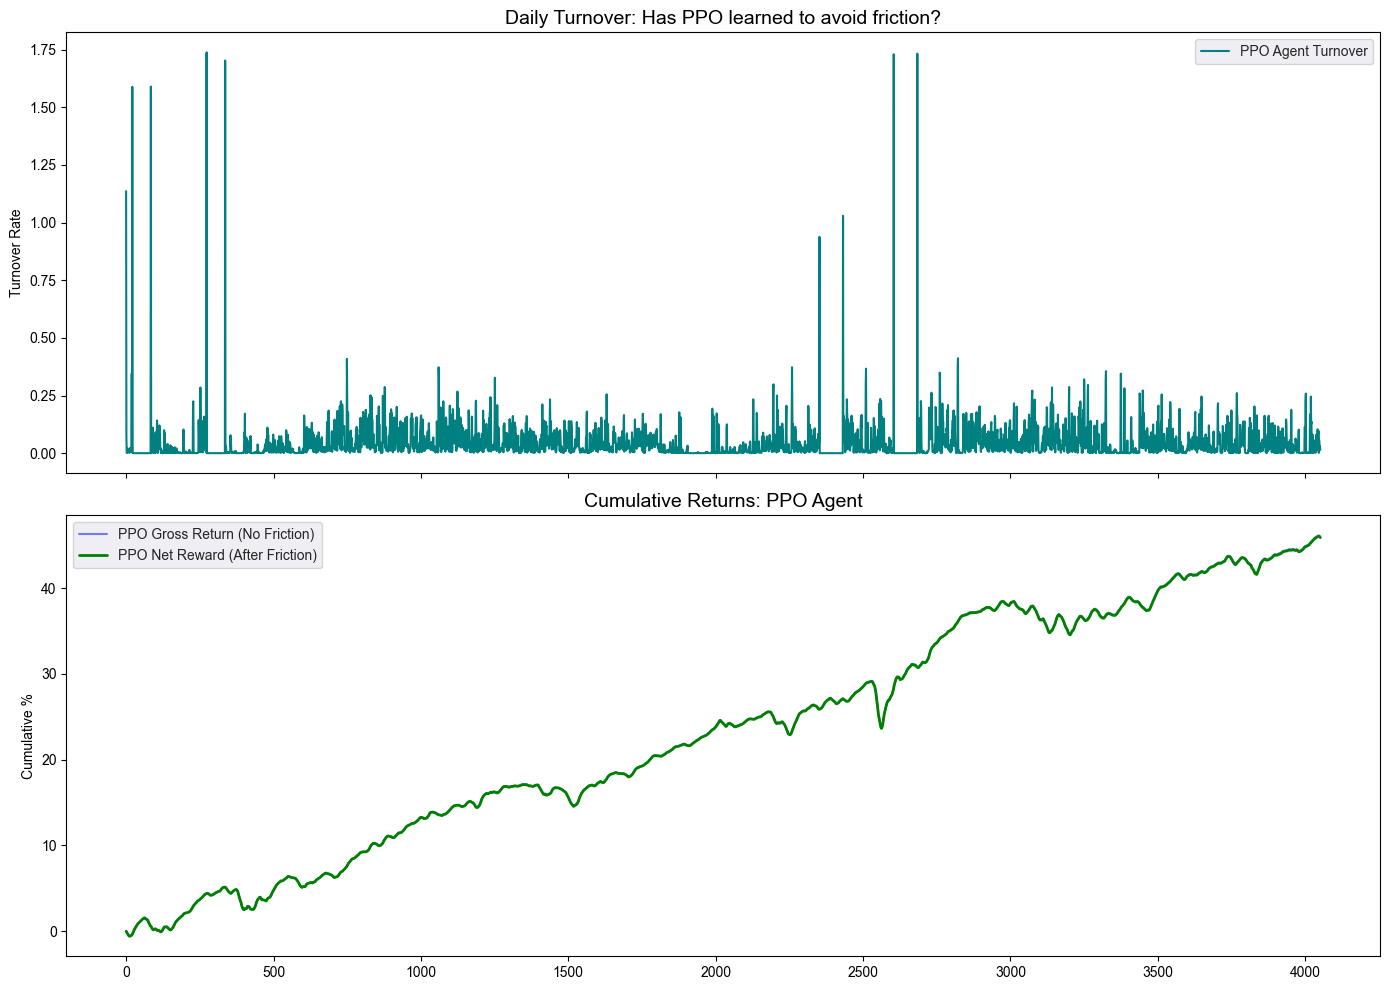

📉 PPO 原始总收益: 4596.99%
🩸 PPO 被抽走的摩擦成本: 9.13%
🏆 PPO 最终真实净收益: 4587.86%


In [17]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("包装环境供 Stable Baselines3 使用...")
# SB3 要求环境必须被包装成向量化环境 (Vectorized Environment)
vec_env = DummyVecEnv([lambda: env])

# 3. 🛡️ 套上终极防护盾：自动归一化观测值 (Observation) 和奖励 (Reward)
# 加上 clip 参数防止极端异常值撑爆网络
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

print("🧠 实例化 PPO 强化学习大脑...")
# 初始化 PPO 模型。使用多层感知机 (MlpPolicy) 来处理 4500 维的特征
model = PPO(
    "MlpPolicy", 
    vec_env, 
    learning_rate=0.0003,
    n_steps=512,      # 每次更新策略前在环境中探索的 rollout 步数
    batch_size=64,     # PPO 的 mini-batch size（注意这里它完全独立于 rollout 数量单独配置）
    verbose=1,
    device="auto"      # 如果你有 Mac M1/M2 (mps) 或者 Nvidia GPU (cuda)，它会自动加速
)

print("🚀 开始训练 Agent (先跑 20,000 步作为一个 Smoke Test)...")
# Agent 将在你的虚拟道指/标普池子里反复爆仓、学习、再爆仓，直到学会敬畏手续费
model.learn(total_timesteps=40000)

print("\n✅ 训练初步完成！重置环境，看看 PPO 现在的操盘水平...")

obs = env.reset()[0] # DummyVecEnv 包装后，reset 返回值略有不同，我们在底层 env 重置
obs, info = env.reset()
terminated = False
truncated = False

ppo_rewards = []
ppo_portfolio_returns = []
ppo_turnovers = []
ppo_transaction_costs = []

while not (terminated or truncated):
    # deterministic=True 表示取消探索，直接输出它认为的最优解
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    ppo_rewards.append(reward)
    ppo_portfolio_returns.append(info['portfolio_return'])
    ppo_turnovers.append(info['turnover'])
    ppo_transaction_costs.append(info['transaction_cost'])

print("🛑 PPO 回测结束。正在生成交易对比报告...")

# 画图对比 PPO 和 之前那只猴子的表现
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.set_style("darkgrid")

# 图1：换手率对比（核心看 PPO 有没有学会降频）
axes[0].plot(ppo_turnovers, color='teal', label='PPO Agent Turnover')
axes[0].set_title("Daily Turnover: Has PPO learned to avoid friction?", fontsize=14)
axes[0].set_ylabel("Turnover Rate")
axes[0].legend()

# 图2：最终净收益 (Net Reward)
axes[1].plot(np.cumsum(ppo_portfolio_returns), label='PPO Gross Return (No Friction)', color='blue', alpha=0.5)
axes[1].plot(np.cumsum(ppo_rewards), label='PPO Net Reward (After Friction)', color='green', linewidth=2)
axes[1].set_title("Cumulative Returns: PPO Agent", fontsize=14)
axes[1].set_ylabel("Cumulative %")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"📉 PPO 原始总收益: {np.sum(ppo_portfolio_returns)*100:.2f}%")
print(f"🩸 PPO 被抽走的摩擦成本: {np.sum(ppo_transaction_costs)*100:.2f}%")
print(f"🏆 PPO 最终真实净收益: {np.sum(ppo_rewards)*100:.2f}%")

In [18]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import numpy as np
import pandas as pd

# ==========================================
# 核心救命操作：截取 30 只股票的 Mini 宇宙
# ==========================================
print("🔪 正在对数据进行降维切片...")
all_tickers = master_df.index.get_level_values('ticker').unique()
# 只取前 30 只股票
mini_tickers = all_tickers[:30]

# 用 loc 切片，并且为了速度，只取最近 1000 个交易日
master_df_mini = master_df.loc[(slice(None), mini_tickers), :].groupby(level='ticker').tail(1000)

print(f"✅ Mini 数据集准备完毕，当前股票数量: {len(mini_tickers)}")

# 重新实例化环境（这回它非常小巧）
env_mini = MultiFactorPortfolioEnv(
    master_df=master_df_mini, 
    feature_cols=feature_cols, 
    commission_rate=0.0005 
)

vec_env = DummyVecEnv([lambda: env_mini])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

print("🧠 实例化 PPO...")
model = PPO(
    "MlpPolicy", 
    vec_env, 
    n_steps=512,         
    batch_size=64,       # 注意：PPO 的 mini-batch size 不会将 rollout 数量计算在内，需单独设定
    policy_kwargs=dict(net_arch=[64, 64]), 
    verbose=1
)

print("🚀 启动 Mini 沙盒 Smoke Test (5000步)...")
model.learn(total_timesteps=5000)
print("🎉 测试通过！Kernel 活下来了！")

🔪 正在对数据进行降维切片...
✅ Mini 数据集准备完毕，当前股票数量: 30
🧠 实例化 PPO...
Using cpu device
🚀 启动 Mini 沙盒 Smoke Test (5000步)...
-----------------------------
| time/              |      |
|    fps             | 4931 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 3745        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.038440615 |
|    clip_fraction        | 0.397       |
|    clip_range           | 0.2         |
|    entropy_loss         | -42.5       |
|    explained_variance   | -0.322      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0626     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0917     |
|    std  